In [39]:
import os
import sys
import matplotlib.pyplot as plt
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [40]:
from config import config_loader as config_loader
from src.data.preprocessing import load_and_filter_catalog
import numpy as np

In [59]:
def load_rf_config(project_root):
    import os
    from src.utils.file_utils import create_save_dir, save_args_to_json
    from config.config_loader import load_args_from_yaml


    args = load_args_from_yaml(os.path.join(project_root, 'config/classifier.yaml'))

    # 添加 RF 专用字段
    Mag_elaps = [4, 4.5, 5] #[6, 6.5, 7, 7.5]
    feature_cols = [
        'Num', 'Mag_max', 'Mag_mean', 'beta', 'b_lsq', 'a_lsq',
        'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk',
        'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk',
        'zvalue'
    ] + [f"T_elaps{Mag}" for Mag in Mag_elaps]

    args.Mag_elaps = Mag_elaps
    args.feature_cols = list(set(feature_cols))
    args.dMag = 0.1
    args_dict = vars(args).copy()
   
    args.save_dir = create_save_dir(os.path.join(project_root,'checkpoints') , model_name='rf',args_dict=args_dict )
    args_dict.pop("save_dir", None)


    for key in list(args_dict.keys()):
        if key in {
            "model", "batch_size", "warmup_ratio", "learning_rate", "weight_decay",
            "scheduler_type", "scheduler_factor", "scheduler_patience", "scheduler_threshold",
            "scheduler_min_lr", "d_model", "d_rnn", "d_inner", "n_layers", "n_head", "d_k",
            "d_v", "t_dropout", "attn_type", "mlp_out", "mlp_dropout", "mlp_hdw", "epochs",
            "cuda_id",
        }:
            del args_dict[key]
    save_args_to_json(args_dict, args.save_dir)
    return args


In [60]:
args = load_rf_config(project_root)

In [61]:
args.save_dir

'/root/autodl-tmp/chuandian_eq/checkpoints/rf_38f29877'

In [62]:
base_dir = os.path.join(project_root,  f"data/{args.dataset}")
df = load_and_filter_catalog(base_dir, Mc=args.Mc)

CSV files found: ['SCEDC.csv', 'processed_SCEDC.csv', 'catalog.csv']


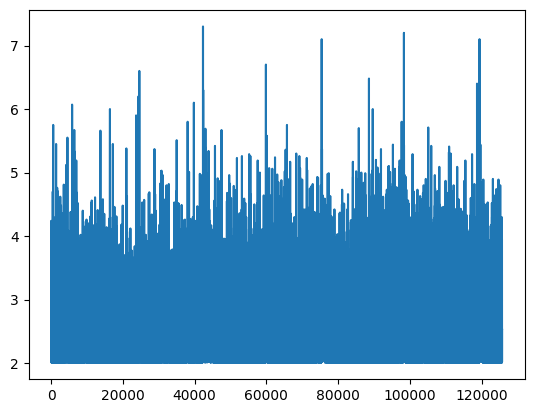

In [63]:
plt.plot(df['Magnitude'])

In [64]:
import src.features.seismic_features as sf
# features_df, num_mag = sf.calculate_seismic_features(
#     df.to_numpy(), 
#     Mc=args.Mc, 
#     Mf=args.Mf, 
#     Twindow=args.Twindow, 
#     Tfore=args.Tfore, 
#     dt=args.dt, 
#     dMag=args.dMag, 
#     Mag_elaps=args.Mag_elaps, 
#     L_max=60,
#     context_len=args.context_len,
# )

In [65]:
from sklearn.preprocessing import MinMaxScaler

def preprocess_data(features_df, feature_cols):
    # 特征缩放
    scaler = MinMaxScaler()
    feature = scaler.fit_transform(features_df[feature_cols])
    
    # 构造标签
    y = np.full(len(features_df), np.nan)
    y[features_df['shock_len'].values > 0] = 1
    y[features_df['Negative'].values == 1] = 0
    
    # 过滤掉无效样本
    valid_mask = (y == 0) | (y == 1)
    y = y[valid_mask]
    feature = feature[valid_mask]
    
    print(f"正样本数量: {np.sum(y == 1)}")
    print(f"负样本数量: {np.sum(y == 0)}")
    
    return feature, y

# feature, y = preprocess_data(features_df, args.feature_cols)

In [66]:
def split_dataset(feature, y, train_ratio=0.8, val_ratio=0.1, seed=0, by_time=False,time_order = ('train', 'val', 'test')):
    from src.data.data_utils import get_split_indices
    train_idx, val_idx, test_idx = get_split_indices(
        len(y), train_ratio=train_ratio, val_ratio=val_ratio, seed=seed, by_time=by_time,time_order=time_order
    )

    # 根据索引划分数据
    f_train = feature[train_idx]
    f_val = feature[val_idx]
    f_test = feature[test_idx]
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]

    return f_train, f_val, f_test, y_train, y_val, y_test

# f_train, f_val, f_test, y_train, y_val, y_test = split_dataset(
#     feature, y, train_ratio=0.8, val_ratio=0.1, seed=0, by_time=args.split_by_time
# )

In [67]:
def print_sample_distribution(y, dataset_name):
    positive_samples = np.sum(y == 1)
    negative_samples = np.sum(y == 0)
    total_samples = len(y)
    positive_ratio = positive_samples / total_samples
    negative_ratio = negative_samples / total_samples

    print(f"Positive samples: {positive_samples}, Negative samples: {negative_samples}")
    print(f"Total samples: {total_samples}, Positive ratio: {positive_ratio:.2f}, Negative ratio: {negative_ratio:.2f}")
    print()

# # 打印每个数据集的样本分布
# print_sample_distribution(y_train, "训练集")
# print_sample_distribution(y_val, "验证集")
# print_sample_distribution(y_test, "测试集")


In [68]:
def prepare_data_rf(args, base_dir=base_dir):
    import src.features.seismic_features as sf
    from src.data.preprocessing import load_and_filter_catalog
    from src.data.data_utils import get_split_indices
    from src.utils.file_utils import save_or_load_data
    from sklearn.preprocessing import MinMaxScaler
    import numpy as np

    # 加载并过滤地震目录
    df = load_and_filter_catalog(base_dir, Mc=args.Mc)

    # 缓存/生成 seismic features
    def generate_data():
        features_df, num_mag = sf.calculate_seismic_features(
            df.to_numpy(),
            Mc=args.Mc,
            Mf=args.Mf,
            Twindow=args.Twindow,
            Tfore=args.Tfore,
            dt=args.dt,
            dMag=args.dMag,
            Mag_elaps=args.Mag_elaps,
            L_max=60,
            context_len=args.context_len,
        )
        return {
            "features_df": features_df,
            "num_mag": num_mag
        }

    cached = save_or_load_data(
        base_path=base_dir,
        generate_fn=generate_data,
        sub_dir="processed/rf_classifier",
        prefix="rf",
        Mc=args.Mc,
        Mf=args.Mf,
        Twindow=args.Twindow,
        Tfore=args.Tfore,
        dt=args.dt,
        dMag=args.dMag,
        Mag_elaps=args.Mag_elaps,
        context_len=args.context_len
    )

    features_df = cached["features_df"]
    num_mag = cached["num_mag"]

    # 特征缩放 + 标签构建
    scaler = MinMaxScaler()
    # feature = scaler.fit_transform(features_df[args.feature_cols])
    feature = features_df[args.feature_cols].values

    y = np.full(len(features_df), np.nan)
   
   
    y[features_df["shock_len"].values > 0] = 1
    y[features_df["Negative"].values == 1] = 0
    
    valid_mask = (y == 0) | (y == 1)
    y = y[valid_mask]
    feature = feature[valid_mask]

    # 划分数据集
    train_idx, val_idx, test_idx = get_split_indices(
        len(y), train_ratio=0.8, val_ratio=0.1, seed=0, by_time=args.split_by_time, time_order=args.time_order
    )

    f_train = feature[train_idx]
    f_val = feature[val_idx]
    f_test = feature[test_idx]
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]

    f_train = scaler.fit_transform(f_train)
    f_val = scaler.transform(f_val)
    
    f_test = scaler.transform(f_test)
    # 打印样本分布
    print_sample_distribution(y_train, "训练集")
    print_sample_distribution(y_val, "验证集")
    print_sample_distribution(y_test, "测试集")

    return df,features_df, f_train, f_val, f_test, y_train, y_val, y_test, num_mag

In [69]:
df,features_df, f_train, f_val, f_test, y_train, y_val, y_test, num_mag = prepare_data_rf(args)

CSV files found: ['SCEDC.csv', 'processed_SCEDC.csv', 'catalog.csv']
[✔] Loading cached data from: /root/autodl-tmp/chuandian_eq/data/SCEDC/processed/rf_classifier/rf_Mag_elaps_4-4.5-5_Mc_2_Mf_5_Tfore_150_Twindow_300_context_len_1_dMag_0.1_dt_10.pkl
Positive samples: 572, Negative samples: 254
Total samples: 826, Positive ratio: 0.69, Negative ratio: 0.31

Positive samples: 35, Negative samples: 68
Total samples: 103, Positive ratio: 0.34, Negative ratio: 0.66

Positive samples: 45, Negative samples: 59
Total samples: 104, Positive ratio: 0.43, Negative ratio: 0.57



In [70]:
print(features_df.columns)

Index(['t', 'Num', 'Mag_max', 'Mag_max_obs', 'Mag_mean', 'b_lsq', 'a_lsq',
       'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk',
       'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk',
       'zvalue', 'beta', 'shock_len', 'Negative', 'T_elaps4', 'T_elaps4.5',
       'T_elaps5'],
      dtype='object')


In [71]:
print(features_df['zvalue'])

0       0.349717
1       0.401777
2       0.332718
3       0.373458
4       0.493244
          ...   
1375   -0.283861
1376   -0.402004
1377   -1.522332
1378   -2.027456
1379   -1.984110
Name: zvalue, Length: 1380, dtype: float64


In [72]:
features_df[features_df['Num']==min(features_df['Num'])]

,t,Num,Mag_max,Mag_max_obs,Mag_mean,b_lsq,a_lsq,b_std_lsq,std_gr_lsq,b_mlk,...,Energy_sqrt,prob_x7_lsq,prob_x7_mlk,zvalue,beta,shock_len,Negative,T_elaps4,T_elaps4.5,T_elaps5
1261,12910.176338,707.0,4.87,5.19,2.464569,1.693097,1.666685,1.605784,54.676845,0.934834,...,3.265810e+10,0.000008,0.001569,-1.034174,6.877689,1.0,0.0,55.813372,73.174676,770.002934


In [73]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(f_train, y_train)
y_prob = rf.predict_proba(f_test)[:, 1]  # 取正类的概率

In [74]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

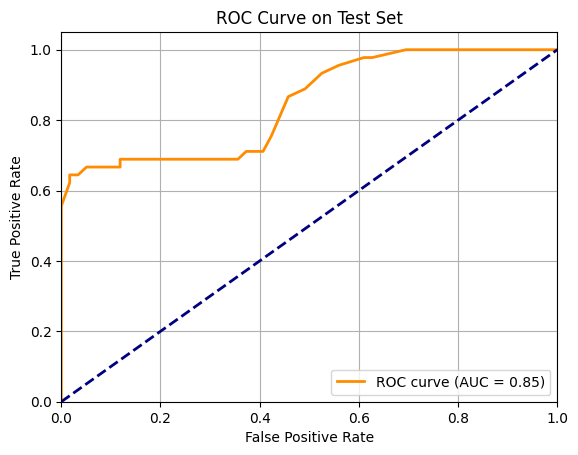

In [75]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # 参考线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(os.path.join(args.save_dir, 'roc_curve.png'))
plt.show()


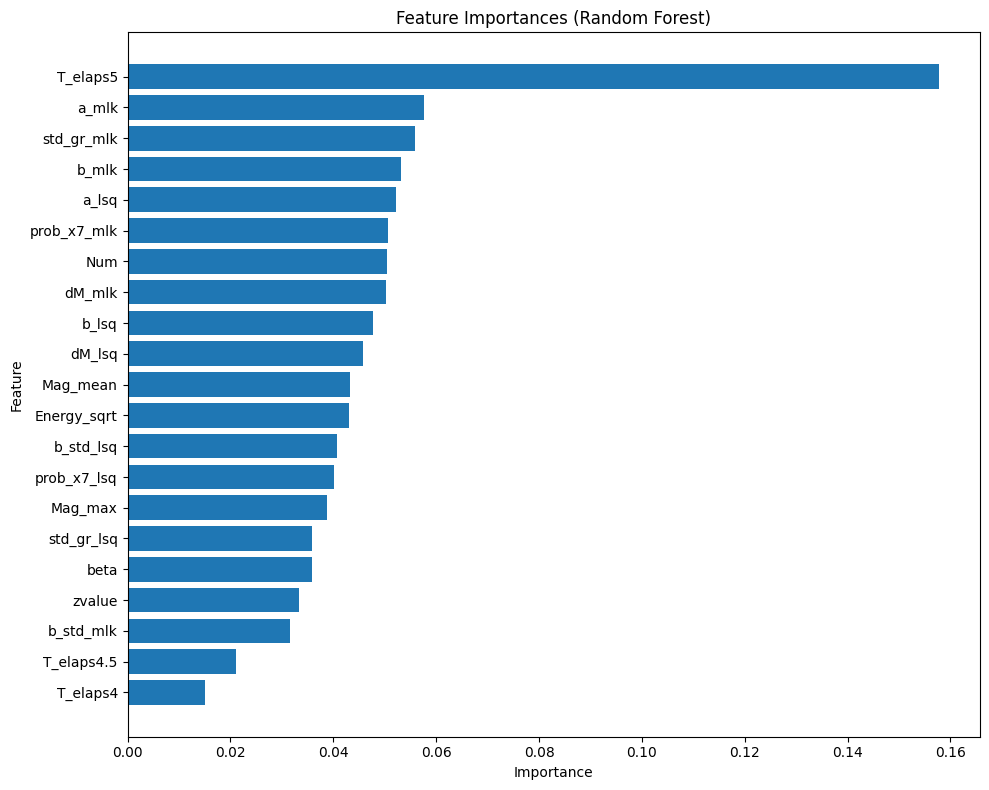

In [76]:
importances = rf.feature_importances_
feature_names = args.feature_cols

indices = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_importances)), sorted_importances, align="center")
plt.yticks(range(len(sorted_importances)), sorted_names)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.gca().invert_yaxis()  
plt.savefig(os.path.join(args.save_dir, 'feature_importances.png'))
plt.show()